# Compute GLORYs EOFs
## Created by Dani Lafarga 8/8/2024

In [2]:
import numpy as np
from numpy import meshgrid
import scipy.io as sc
import os
from pprint import pprint
import matplotlib.pyplot as plt
from numpy import linspace
from numpy import meshgrid
#from mpl_toolkits.basemap import Basemap
import matplotlib as mpl
import matplotlib
import math
import time
import csv
import netCDF4 as nc 
from netCDF4 import Dataset as ds

from ipywidgets import interact, interactive, fixed, interact_manual
import ipywidgets as widgets

from matplotlib import cm
from matplotlib.colors import ListedColormap, LinearSegmentedColormap
top2 = cm.get_cmap('winter')
bottom2 = cm.get_cmap('hot_r')
newcolors2 = np.vstack((top2(np.linspace(0, 1, 128)),   # I want all of the winter cmap and it will only explain 100 points
                    bottom2(np.linspace(.1, .9, 128)))) # I dont want the extremes of hot cmap but it will explain 128 points
newcmp2 = ListedColormap(newcolors2, name='OrangeBlue')

import warnings
warnings.filterwarnings("ignore")

def set_directory():
    global data_directory
    path = 'F:/GLORYS/'
    if not os.path.exists(path):
        data_directory = '/Volumes/Elements/GLORYS'
    else:
        data_directory = path
    return

#################################################################################################################
#################################################################################################################

# Function creates a folder if it doesnt already exist
# Input:
#         - folder_path: string with the path name to folder

def create_folder(folder_path):
    
    if not os.path.exists(folder_path):
        os.makedirs(folder_path)
        print(f"Folder '{folder_path}' created.")
    else:
        print(f"Folder '{folder_path}' already exists.")
set_directory()
#################################################################################################################
#################################################################################################################
# Function get_var() will get common variables that will be required for climatologies,
# anomalies, and EOFs
# Input: 
#         - MON_INDEX: month index tells us home many years we will have 
#              Months 1-6 have 29 years
#              Months 7-12 only have 28 years
#              MON_INDEX = 0 means 3 month season
# Output: 
#         - lat: 1d array with all latitude values
#         - lon: 1d array with all longitude values
#         - depth: 1d array with all depth values
#         - years: 1d array with all year values
def get_var():
    fn     = 'thetao.mon.mean.1994.nc'
    fn     = os.path.join(data_directory, fn)
    fn     =  ds(fn,'r')
    lat    = fn.variables['latitude'][:].data    # read in latitude
    lon    = fn.variables['longitude'][:].data   # read in longitude
    depths = fn.variables['depth'][:].data       # read in depth
    fn.close()
    return lat, lon, depths
#################################################################################################################
#################################################################################################################
# Function compute volume weights based on latitude and depthe values. Although longitude values are not
# in the equation the length of the longitude array is necessary for building 3D volume weight array 
# Input:
#         - lat: 1d array with all latitude values
#         - lon: 1d array with all longitude values
#         - depth: 1d array with all depth values
# Output: 
#         - area_weight: 3D array 
def vol_weight(depths, lon, lat):
    xx, yy = meshgrid(lon, lat)
    tot_depth = len(depths)
    
    # area weight for lattitude values
    area_w = np.cos(yy*math.pi/180)
    if lat[-1] == 90.0:
        area_w[-1,:] = 0.0
    # area weights for depth
    area_weight = []
    for i in range(tot_depth):
        if i == 0:
            area_weight.append(np.sqrt(depths[0] * area_w)) # first depth thickness
        else:
            area_weight.append( np.sqrt((depths[i] - depths[i - 1]) * area_w))
    # Turning weights into one array
    area_weight = np.array(area_weight)
    return area_weight


C:\Users\bubby\AppData\Local\Temp\ipykernel_16316\3356880309.py:23: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  top2 = cm.get_cmap('winter')
C:\Users\bubby\AppData\Local\Temp\ipykernel_16316\3356880309.py:24: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  bottom2 = cm.get_cmap('hot_r')


In [3]:
month = 'Winter Avg'

lat, lon, depths = get_var()


####### SELECT REGION ########
'''
region = "Pacific"


# for the entire Pacific
lat_start = 720
lat_end   = 1801
lon_start = 1440
lon_end   = 3600

# Not sure which one to do
#depth_end = len(depths)
depth_end = 32
'''

region = "Global"

# Global
lat_start = 0
lat_end   = len(lat)
lon_start = 0
lon_end   = len(lon)
depth_end = len(depths)


############################



EOF_directory  = os.path.join(data_directory, '2D EOFs/' + month + "/" +region + "/")
create_folder(EOF_directory)
anomalies_directory = os.path.join(data_directory, 'Anomalies/Winter Avg' )

Folder 'F:/GLORYS/2D EOFs/Winter Avg/Global/' already exists.


In [4]:

'''
lat, lon, depths = get_var()



# for the NP
lat_start = 1200
lat_end   = 1741
lon_start = 1260
lon_end   = 3121
'''

'''
# for the entire Pacific
lat_start = 720
lat_end   = 1801
lon_start = 1440
lon_end   = 3600
'''

'''
# Global
lat_start = 0
lat_end   = len(lat)
lon_start = 0
lon_end   = len(lon)
depth_end = len(depths)

'''


#lat, lon, depths = get_var()
fn     = 'Anomalies/Jan/Jan.anom.mon.1993.nc'
fn     = os.path.join(data_directory, fn)
fn     =  ds(fn,'r')
lat    = fn.variables['lat'][:].data    # read in latitude
lon    = fn.variables['lon'][:].data   # read in longitude
depths = fn.variables['Z'][:].data       # read in depth
fn.close()


years  = np.linspace(1994, 2021,28, dtype="int")
cut_lat = lat[lat_start:lat_end]
cut_lon = lon[lon_start:lon_end]
cut_depths = depths[:depth_end]

## Compute Covariance

In [4]:
#################################################################################################################
#################################################################################################################
# Function reads in cut anomalies, will tak eout NaNs, and then flattten to a 1D array
# 
# Input:
#         - year: int with the year to read in
# Output:
#         - anom: 1d array that contains anomalies of the file without any NaN
def read_anom_compressed(year,depth):
    fn   = 'Winter.anom.mon.'+str(year)+'.nc'         # change directory
    fn   = os.path.join(anomalies_directory, fn)  # join with the directory that can be changed
    nc0  = ds(fn, 'r')
    anom = nc0.variables['anom'][depth, lat_start:lat_end, lon_start:lon_end]
    anom = anom.compressed()                        # flatttentens and gets rid of NaN
    nc0.close()
    return anom
#################################################################################################################
#################################################################################################################
# Function computes the covariance matrix in time for the data. 
# Covariance is computed by doing the dot product of one anomally array at time t
# with all other anomalies at time t'. 
# to avoid redundancies the code will explot the symmetry of the covariance matrix
'''
Example
   Anomaly Mult: 
            let t = 2
                   o t' = t+1
                                        anom(t) * anom(t+1) = a
                                        -> cov(2,3) = cov(3,2) = a
                   o t' = t+2
                                        anom(t) * anom(t+2) = b
                                        -> cov(2,4) = cov(4,2) = b
                   o t' = t+3
                                        anom(t) * anom(t+3) = c
                                        -> cov(2,5) = cov(5,2) = c
                                                ┌               ┐
                                        cov =   │  # # # # # #  │
                                                │  # # # # # #  │
                                                │  # # t a b c  │
                                                │  # # a # # #  │
                                                │  # # b # # #  │
                                                │  # # c # # #  │
                                                └               ┘
'''
# Input:
#         - years: 1D array of ints with all years to be used in computation. These are all 
#                  the anomalies which will be read in 
# Output:
#         - covariance_mat: 2D covariance matrix(floats)
# Important Variables:   
#         - Y: total amount of years. This will give us the dimensions for our square covariance matrix (Y by Y)
#         - t: the time index(int). this will tell us what diagonal we are on so we can exploit symmetry.
#         - anom: anomalies at time t. 
#         - t_prime: all values from t+1 to the last time step index(int)
#         - year_prime: the year value of t_prime
#             example: years = [1993, 2021], if t = 0 so year = 1993, t' = 1:29, and year' = 1994:2021
#         - anom_tprime: anomalies at time t'
def cov_mat(years, depth):
    Y = len(years)
    covariance_mat = np.zeros((Y,Y))
    for t,year in enumerate(years):
        anom = read_anom_compressed(year, depth)
        for t_prime,year_prime in enumerate(years[t:]):
            anom_tprime = read_anom_compressed(year_prime,depth)
            covariance_mat[t,t + t_prime] = np.dot(anom, anom_tprime)
            covariance_mat[t + t_prime,t] = covariance_mat[t,t + t_prime]
    return covariance_mat

In [5]:
start = time.time()
cov = np.zeros((len(cut_depths), len(years), len(years)))
for depth_ind in enumerate(cut_depths):
   cov[depth_ind[0],:,:] = cov_mat(years,depth_ind[0])
# cov = cov_mat(years,0)
end = time.time()
print(end-start)

1899.0990281105042


## Compute eigenvalues/eigenvectors

In [10]:
#################################################################################################################
#################################################################################################################
# Function computes eigenvectors and values of the covariance matrix and sort them by variance greatest to least
# function will also check to make sure they are normalized and orthogonal
# Input:
#         - cov: 2D covariance matrix. Cannot have any NaNs!
# Output:
#         - eigvals: 1D array with all eigenvalues of covariance matrix sorted (float)
#         - eigvecs: 2D matrix with corresponding sorted eigenvectors of covariance matrix (float)
# Important Variables: 
def find_eigen(cov):
    eigvals, eigvecs = np.linalg.eig(cov)
    eigvecs = np.array(eigvecs)
    
    # Check to make sure vectors are orthogonal
    n, m = eigvecs.shape
    for col_i in range(m):
        for col_j in range(m):
            if col_i < col_j:  # use strictly less than because we don't want to consider a column with itself, and the dot product is commutable so order doesn't matter
                is_orthogonal = np.dot(eigvecs[:, col_i], eigvecs[:, col_j])
                if not np.isclose(is_orthogonal, 0):
                    raise ValueError(f"Eigenvector {col_i} and Eigenvector {col_j} are not orthogonal.")
    # checking magnitude of evals
    for col_i in range(m):
        is_one = np.linalg.norm(eigvecs[:,col_i])
        if not np.isclose(is_one, 1):
            raise ValueError(f"Eigenvector {col_i} is not one")
            
    # sort eigenvalues and eigenvectors
    eig_index = np.argsort(eigvals)
    eig_index = np.flip(eig_index)
    
    new_eigvals = eigvals[eig_index[:]]
    eigvals = new_eigvals
    
    new_eigvecs = eigvecs[:,eig_index]
    eigvecs = new_eigvecs 
    return eigvals,eigvecs
#################################################################################################################
#################################################################################################################
# Function saves eigenvalues and eigencvectors into a csv file 
# 
# Input:
#         - eigvals: 1D array with eigenvalues
#         - eigvecs: 2D matrix with eigenvectors
#         - month: string with the month the eigenvec/eigenvals belong to
# Output:
#         - None: function saves to a file 
def save_evals(eigvals,eigvecs,month):
    # Prepare data for saving
    # Create a 2D array with eigenvalues and eigenvectors
    data = np.hstack((eigvals.reshape(-1, 1), eigvecs.T))
    
    # Save to CSV file
    create_folder(EOF_directory)
    fn     = month+'_eigenvalues_eigenvectors.csv'
    fn     = os.path.join(EOF_directory, fn)
    with open(fn, 'w', newline='') as file:
        writer = csv.writer(file)
        
        # Write the header
        header = ['Eigenvalue'] + [f'Eigenvector {i+1}' for i in range(eigvecs.shape[1])]
        writer.writerow(header)
        
        # Write the data
        for row in data:
            writer.writerow(row)
    
    print("Eigenvalues and eigenvectors saved to 'eigenvalues_eigenvectors.csv'")




import pandas as pd
#################################################################################################################
#################################################################################################################
# Function saves eigenvalues and eigencvectors into a csv file 
# 
# Input:
#         - eigvals: 1D array with eigenvalues
#         - eigvecs: 2D matrix with eigenvectors
#         - month: string with the month the eigenvec/eigenvals belong to
# Output:
#         - None: function saves to a file
def save_evals(eigvals,eigvecs,month):
    create_folder(EOF_directory)
    fn     = month+'_eigenvalues_eigenvectors.xlsx'
    fn     = os.path.join(EOF_directory, fn)
    writer = pd.ExcelWriter(fn, engine='xlsxwriter')
    for i in range(len(cut_depths)):
        data = np.hstack((eigvals[:,i].reshape(-1, 1), eigvecs[i,:,:].T))
        df = pd.DataFrame(data)
        header = ['Eigenvalue'] + [f'Eigenvector {i+1}' for i in range(eigvecs.shape[1])]
        df.columns = header
        df.to_excel(writer, sheet_name='bin%d' % i)
    writer.close()

In [11]:
#eigvals, eigvecs = find_eigen(cov) # for one depth

eigvals = np.zeros((len(years),len(cut_depths)))
eigvecs = np.zeros((len(cut_depths), len(years), len(years)))
for depth_ind in enumerate(cut_depths):
    eigvals[:,depth_ind[0]],eigvecs[depth_ind[0],:,:] = find_eigen(cov[depth_ind[0],:,:])

In [12]:
save_evals(eigvals,eigvecs, month)

Folder 'F:/GLORYS/2D EOFs/Winter Avg/Global/' already exists.


In [13]:
'''
import matplotlib.pyplot as plt
#import plot_all
title_sz = 19
label_sz = title_sz
tick_sz = 5
line = 3

depth_ind = 0
fig = plt.figure(figsize=(15., 7.))

ax = fig.add_subplot(2,1,1)
mode = 1
plot_all.pc_plot_multi_fig(mode, eigvecs[:,:], years)
plt.title('2D Winter Avg PC ' + str(mode) +' at Surface', fontsize = title_sz)
plt.ylabel('(a)', rotation = 'horizontal', size = label_sz)
ax.set_xticklabels([])  # Remove x tick labels
plt.grid(True)

ax = fig.add_subplot(2,1,2)
mode = 2
plot_all.pc_plot_multi_fig(mode, -eigvecs[:,:], years)
plt.title('2D Winter Avg PC ' + str(mode) +' at Surface', fontsize = title_sz)
plt.ylabel('(b)', rotation = 'horizontal', size = label_sz)
plt.xlabel('Year', fontsize = label_sz)
plt.grid(True)
#plt.savefig('E:/Paper Figs/2D NP Winter PC.png', dpi=300, bbox_inches='tight')
plt.show()
'''

"\nimport matplotlib.pyplot as plt\n#import plot_all\ntitle_sz = 19\nlabel_sz = title_sz\ntick_sz = 5\nline = 3\n\ndepth_ind = 0\nfig = plt.figure(figsize=(15., 7.))\n\nax = fig.add_subplot(2,1,1)\nmode = 1\nplot_all.pc_plot_multi_fig(mode, eigvecs[:,:], years)\nplt.title('2D Winter Avg PC ' + str(mode) +' at Surface', fontsize = title_sz)\nplt.ylabel('(a)', rotation = 'horizontal', size = label_sz)\nax.set_xticklabels([])  # Remove x tick labels\nplt.grid(True)\n\nax = fig.add_subplot(2,1,2)\nmode = 2\nplot_all.pc_plot_multi_fig(mode, -eigvecs[:,:], years)\nplt.title('2D Winter Avg PC ' + str(mode) +' at Surface', fontsize = title_sz)\nplt.ylabel('(b)', rotation = 'horizontal', size = label_sz)\nplt.xlabel('Year', fontsize = label_sz)\nplt.grid(True)\n#plt.savefig('E:/Paper Figs/2D NP Winter PC.png', dpi=300, bbox_inches='tight')\nplt.show()\n"

## Variance explained by EOF Modes 1 and 2 at each depth layer

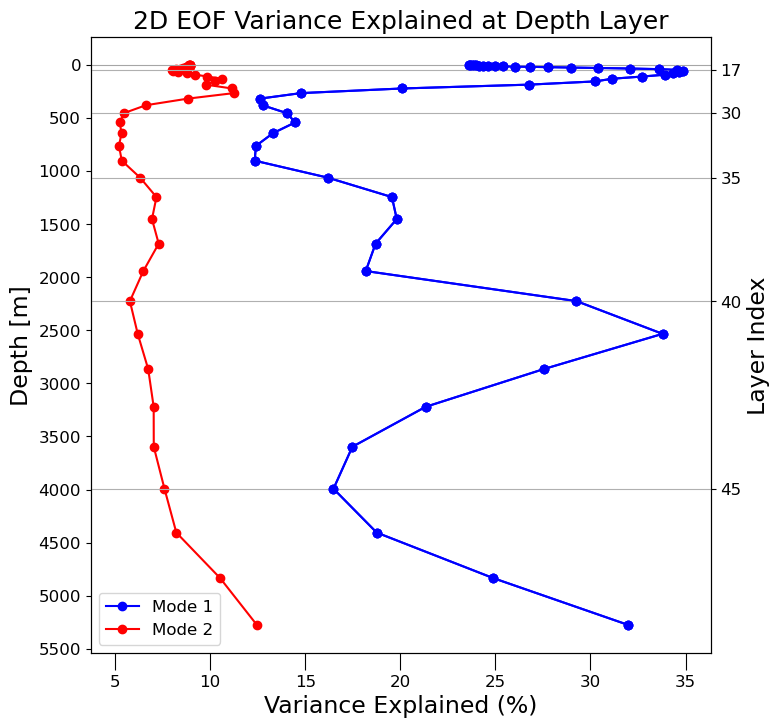

In [80]:
#################################################################################################################
#################################################################################################################
# Function computes scree plot calculations by depth and saves EOF specific variance value to an array
# Input:
#         - mode: EOF # of choice
# Output:
#         - variance_array: np array of length(depths) with % variance explained by EOF 
# Important Variables: 
def eof_array(mode):
    mode = mode-1
    # Initialize zero array
    variance_array = []
    # For all depths
    for i in range(depth_end):
        # compute cummulative variance for depth layer
        cumulative_eval = np.cumsum(eigvals[:,i])
        # assign percentage variance for mode to array
        variance_array.append((eigvals[mode,i]/cumulative_eval[-1])*100)

    return(variance_array)



# Create % variance for first two EOF's
mode1 = eof_array(1)
mode2 = eof_array(2)
# Sum of EOF 1 and 2
bothModes = np.add(mode1, mode2)

# Depth Layer
depthLayer = 0-np.array(cut_depths[:depth_end])





'''

## Try with Dataframe object
d = {"EOF 1": mode1, "EOF 2": mode2, "EOF 1 + 2": bothModes, "Depth (m)": depthLayer}
df = pd.DataFrame(data = d).melt(id_vars = "Depth (m)", var_name = "Mode", value_name = "Percentage Variance")
df.plot(x = "Percentage Variance", y = "Depth (m)")
'''

#print(df)



# Create Fig, Ax
fig, ax1 = plt.subplots()

# Format 
fig.set_size_inches(8., 8.)
title_sz = 18
label_sz = title_sz - 1
tick_sz = title_sz -6

p1 = plt.plot(mode1, depthLayer, 'b', marker = 'o', label = 'Mode 1')

p2 = plt.plot(mode2, depthLayer, "r", marker = "o", label = "Mode 2")

# Format X axis
ax1.set_xlabel("Variance Explained (%)", size = label_sz)
ax1.tick_params('x',size = tick_sz, labelsize = tick_sz)
#ax1.grid(axis = "x")


# Format Left hand y axis
ax1.set_ylabel('Depth [m]', size =label_sz)
step = 500                            # change this for smaller depth intervals
y_labels = ax1.get_yticks()
dep_names = np.arange(0,-y_labels[0],step).astype(int)
ax1.set_yticks(-dep_names, dep_names.astype(str).tolist(), fontsize = tick_sz)
ax1.axhline(y = 0, color='0.65', linestyle='-', label='', lw = '0.8')



# Legend and Title
plt.legend(fontsize = tick_sz) 
plt.title("2D EOF Variance Explained at Depth Layer", size = title_sz)

# Create right hand y axis
ax2 = ax1.twinx()
ax2.plot(mode1, depthLayer, "bo")
dep_ind = np.arange(32).astype(str).tolist()



# Select based on depth of plot
indexLabels = [0, 12, 17, 21, 24, 26, 28, 30]     # first 32
indexLabels = [17, 30, 35, 40, 45]

layerIndex = depthLayer[indexLabels]
ax2.set_yticks(layerIndex, indexLabels, fontsize = tick_sz)
ax2.set_ylabel('Layer Index', size =label_sz)
ax2.grid(axis = "y")


# Create Plots
p1 = plt.plot(mode1, depthLayer, 'b', marker = 'o', label = 'Mode 1')
#p3 = plt.plot(bothModes, depthLayer, "g", marker = "o", label = "Modes 1 + 2")



saveName = 'D:/SCIL/Paper Figs/' + region + '/2D DJF Percent Variance by Depth.png'
plt.savefig(saveName, dpi=300, bbox_inches='tight')
plt.show()

In [17]:
depths[26]

222.4752

## Scree Plots

In [35]:
from ipywidgets import interact, interactive, fixed, interact_manual
import ipywidgets as widgets
def f(depth_ind):
    num_eval = np.arange(eigvals.shape[0])+1 # mode numbers
    cumulative_eval = np.cumsum(eigvals[:,depth_ind]) # compute cummulative variance
    fig, ax = plt.subplots()
   
    fig.set_size_inches(8., 5.)
    title_sz = 15
    label_sz = title_sz-3
    tick_sz = 5
   
    # plotting Percentage Variance
    p1, = plt.plot(num_eval,(eigvals[:,depth_ind]/cumulative_eval[-1])*100, 'b',marker = 'o',label = 'Percentage Variance')
    # formatting for left axis
    ax.set_ylabel("Percentage Variance", size = label_sz)
    ax.tick_params('y', colors='b',size = tick_sz, labelsize = label_sz-2)
    ax.yaxis.label.set_color('blue')
    plt.xticks(fontsize= label_sz-2)
   
    # plotting Cummulative Percentage Variance
    ax2 = ax.twinx()
    p2, = plt.plot(num_eval,(cumulative_eval/cumulative_eval[-1])*100,'r',marker = 'x',label = 'Cumulative Percentage Variance')
   
    # formatting for right axis
    ax2.tick_params('y', colors='r',size = tick_sz, labelsize = label_sz-2)
    ax2.set_ylabel("Cumulative Percentage Variance", size = label_sz)
    ax2.yaxis.label.set_color('red')
   
    depth_name = str(depth_ind + 1)
    plt.legend(handles=[p1,p2],loc='center right', fontsize = label_sz-5)
    plt.title(month+ ' Scree Plot Depth: '+ depth_name, size = title_sz)

    saveName = 'D:/SCIL/Paper Figs/2D Winter Pacific Scree_Depth_' + str(depth_ind) + ".png"
    plt.savefig(saveName, dpi=300, bbox_inches='tight')
        
    plt.show()
    
interactive(f, depth_ind = (0,len(cut_depths)-1))




interactive(children=(IntSlider(value=24, description='depth_ind', max=49), Output()), _dom_classes=('widget-i…

## Compare to 3D

In [39]:
import pandas as pd

fn = 'F:/GLORYS/cut_EOFs/Winter Avg/' + region + '/Winter Avg_eigenvalues_eigenvectors.csv'

df = pd.read_csv(fn)

eigvals3d = df["Eigenvalue"].to_numpy()
eigvals3d

num_eval = np.arange(eigvals3d.shape[0])+1 # mode numbers
cumulative_eval = np.cumsum(eigvals3d) # compute cummulative variance
percVariance = (eigvals3d/cumulative_eval[-1])*100

df = pd.DataFrame(percVariance, columns = ["3D"])
df["Mode"] = num_eval
df

,3D,Mode
0,18.454141,1
1,11.569150,2
2,5.171328,3
3,4.575679,4
4,4.171130,5
5,3.991977,6
6,3.587803,7
7,3.354576,8
8,3.027347,9
9,2.855903,10


In [40]:


for i in range(depth_end):
    
    cumEval = np.cumsum(eigvals[:,i]) # compute cummulative variance
    pV = (eigvals[:,i]/cumEval[-1])*100

    colName = str(i)

    df[colName] = pV

newDF = df[:3]
newDF

,3D,Mode,0,1,2,3,4,5,6,7,...,40,41,42,43,44,45,46,47,48,49
0,18.454141,1,23.592443,23.689196,23.784201,23.876862,23.985110,24.122605,24.358906,24.621177,...,29.263947,33.791574,27.535050,21.329638,17.476666,16.483913,18.758457,24.876846,31.982493,NaN
1,11.569150,2,8.872421,8.895591,8.915637,8.926883,8.932443,8.933192,8.924915,8.912009,...,5.775675,6.187550,6.738940,7.026913,7.031517,7.595433,8.217879,10.518024,12.454334,NaN
2,5.171328,3,6.154371,6.141753,6.125716,6.112060,6.099488,6.087099,6.065227,6.049452,...,4.301129,4.407986,4.365392,4.466767,4.796341,5.459656,6.574529,6.997496,8.857677,NaN


In [41]:
newDF = df[:3]

for i in range(depth_end):

    colName = str(i)

    
    newDF[colName] = newDF[colName].sub(newDF["3D"])

#newDF["3D"] = 0

newDF = newDF.drop("3D", axis = 1)

print(newDF.abs().sum())

newDF.loc['Total'] = newDF.abs().sum()

newDF


Mode     6.000000
0        8.818075
1        8.879040
2        8.937962
3        9.005721
4        9.095837
5        9.220194
6        9.442900
7        9.702301
8       10.050444
9       10.500012
10      11.088146
11      11.824873
12      12.731351
13      13.828693
14      15.151677
15      16.802004
16      18.631656
17      20.068621
18      20.834508
19      20.976109
20      20.685476
21      19.896015
22      17.704905
23      15.466349
24      14.619033
25      10.739674
26       2.394716
27       4.117695
28       8.827531
29      10.979082
30      10.665706
31      10.579447
32      11.720260
33      12.584523
34      12.381171
35       7.668792
36       5.800545
37       6.085223
38       4.533674
39       5.882708
40      17.473481
41      21.482375
42      14.717056
43       8.122296
44       5.890096
45       6.232274
46       5.058789
47       9.299999
48      18.099884
49       0.000000
dtype: float64


,Mode,0,1,2,3,4,5,6,7,8,...,40,41,42,43,44,45,46,47,48,49
0,1.0,5.138303,5.235055,5.330060,5.422721,5.530969,5.668465,5.904765,6.167036,6.513897,...,10.809806,15.337433,9.080909,2.875497,-0.977475,-1.970228,0.304316,6.422705,13.528352,NaN
1,2.0,-2.696730,-2.673560,-2.653514,-2.642267,-2.636707,-2.635959,-2.644235,-2.657142,-2.679887,...,-5.793476,-5.381600,-4.830210,-4.542238,-4.537634,-3.973718,-3.351271,-1.051126,0.885183,NaN
2,3.0,0.983043,0.970425,0.954388,0.940732,0.928160,0.915771,0.893899,0.878124,0.856661,...,-0.870199,-0.763342,-0.805936,-0.704561,-0.374987,0.288327,1.403201,1.826168,3.686349,NaN
Total,6.0,8.818075,8.879040,8.937962,9.005721,9.095837,9.220194,9.442900,9.702301,10.050444,...,17.473481,21.482375,14.717056,8.122296,5.890096,6.232274,5.058789,9.299999,18.099884,0.0


In [42]:

two = newDF[:3].transpose()
two.columns = two.iloc[0]
new = two.drop("Mode")

new["Depth"] = range(1, len(new) + 1)

# new.melt(id_vars = ['Depth'], var_name = "Mode", value_name = "diff").groupby("Mode").plot(x = "diff", y = "Depth")
new

Mode,1.0,2.0,3.0,Depth
0,5.138303,-2.696730,0.983043,1
1,5.235055,-2.673560,0.970425,2
2,5.330060,-2.653514,0.954388,3
3,5.422721,-2.642267,0.940732,4
4,5.530969,-2.636707,0.928160,5
5,5.668465,-2.635959,0.915771,6
6,5.904765,-2.644235,0.893899,7
7,6.167036,-2.657142,0.878124,8
8,6.513897,-2.679887,0.856661,9
9,6.967536,-2.709847,0.822629,10


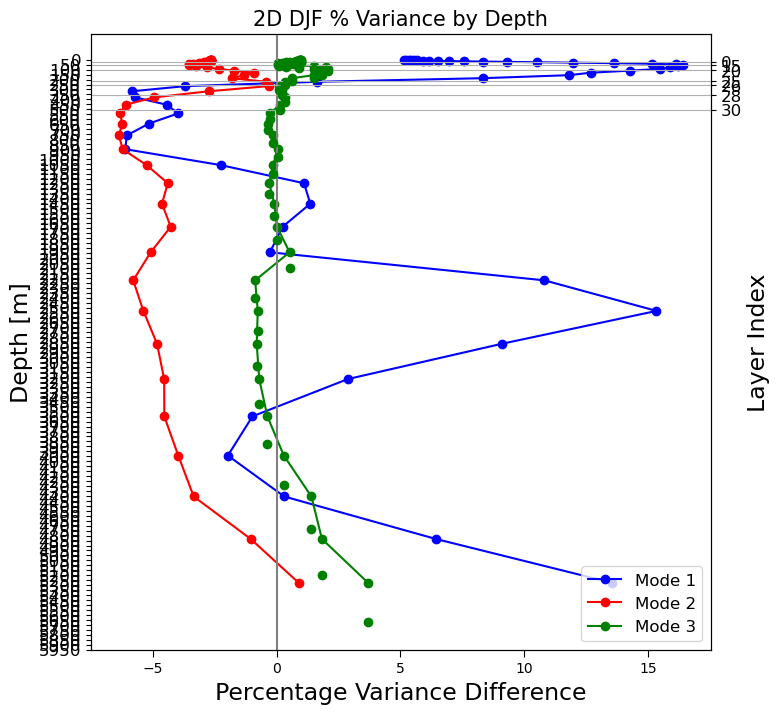

In [43]:
mode1diff = new[1].to_numpy()
mode2diff = new[2].to_numpy()
mode3diff = new[3].to_numpy()


# Create Fig, Ax
fig, ax1 = plt.subplots()

# Format 
fig.set_size_inches(8., 8.)
title_sz = 15
label_sz = title_sz-3
tick_sz = 5



# Create Plots
p1 = plt.plot(mode1diff, depthLayer, 'b', marker = 'o', label = 'Mode 1')
p2 = plt.plot(mode2diff, depthLayer, "r", marker = "o", label = "Mode 2")
p3 = plt.plot(mode3diff, depthLayer, "g", marker = "o", label = "Mode 3")

# Format X axis
ax1.set_xlabel("Percentage Variance Difference", size = label_sz+5)
ax1.tick_params('x',size = tick_sz, labelsize = label_sz-2)
#ax1.grid(axis = "x")


# Format Left hand y axis
ax1.set_ylabel('Depth [m]', size =label_sz+5)
step = 500                             # change this for smaller depth intervals
y_labels = ax1.get_yticks()
dep_names = np.arange(0,-y_labels[0],step).astype(int)
ax1.set_yticks(-dep_names, dep_names.astype(str).tolist(), fontsize = label_sz)

# Legend and Title
plt.legend(fontsize = label_sz, loc = "lower right") 
plt.title("2D DJF % Variance by Depth", size = title_sz)
plt.axvline(color = "grey")


# Create right hand y axis
ax2 = ax1.twinx()
ax2.plot(mode3diff, depthLayer, "go")
dep_ind = np.arange(32).astype(str).tolist()
indexLabels = [0, 15, 20, 25, 26, 28, 30]
layerIndex = depthLayer[indexLabels]
ax2.set_yticks(layerIndex, indexLabels, fontsize = label_sz)
ax2.set_ylabel('Layer Index', size =label_sz+5)
ax2.grid(axis = "y")




plt.show()




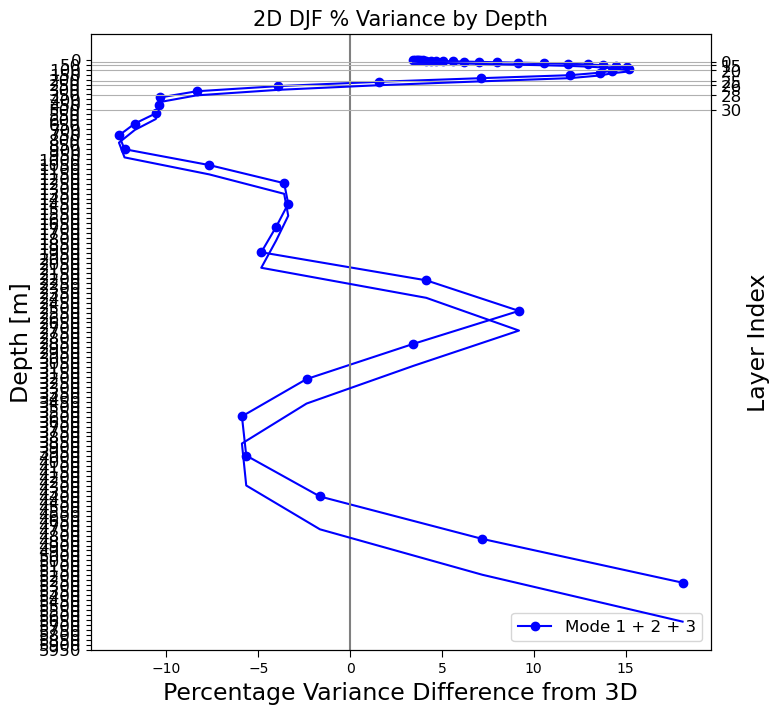

In [47]:
total_diff = mode1diff + mode2diff + mode3diff

# Create Fig, Ax
fig, ax1 = plt.subplots()

# Format 
fig.set_size_inches(8., 8.)
title_sz = 15
label_sz = title_sz-3
tick_sz = 5



# Create Plots
p1 = plt.plot(total_diff, depthLayer, 'b', marker = 'o', label = 'Mode 1 + 2 + 3')


# Format X axis
ax1.set_xlabel("Percentage Variance Difference from 3D", size = label_sz+5)
ax1.tick_params('x',size = tick_sz, labelsize = label_sz-2)
#ax1.grid(axis = "x")


# Format Left hand y axis
ax1.set_ylabel('Depth [m]', size =label_sz+5)
step = 500                            # change this for smaller depth intervals
y_labels = ax1.get_yticks()
dep_names = np.arange(0,-y_labels[0],step).astype(int)
ax1.set_yticks(-dep_names, dep_names.astype(str).tolist(), fontsize = label_sz)

# Legend and Title
plt.legend(fontsize = label_sz, loc = "lower right") 
plt.title("2D DJF % Variance by Depth", size = title_sz)
plt.axvline(color = "grey")


# Create right hand y axis
ax2 = ax1.twinx()
ax2.plot(total_diff, depthLayer, "blue")
dep_ind = np.arange(32).astype(str).tolist()
indexLabels = [0, 15, 20, 25, 26, 28, 30]
layerIndex = depthLayer[indexLabels]
ax2.set_yticks(layerIndex, indexLabels, fontsize = label_sz)
ax2.set_ylabel('Layer Index', size =label_sz+5)
ax2.grid(axis = "y")


plt.show()

#plt.savefig("2)


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


<Axes: xlabel='Mode', ylabel='Percentage Variance Difference from 3D'>

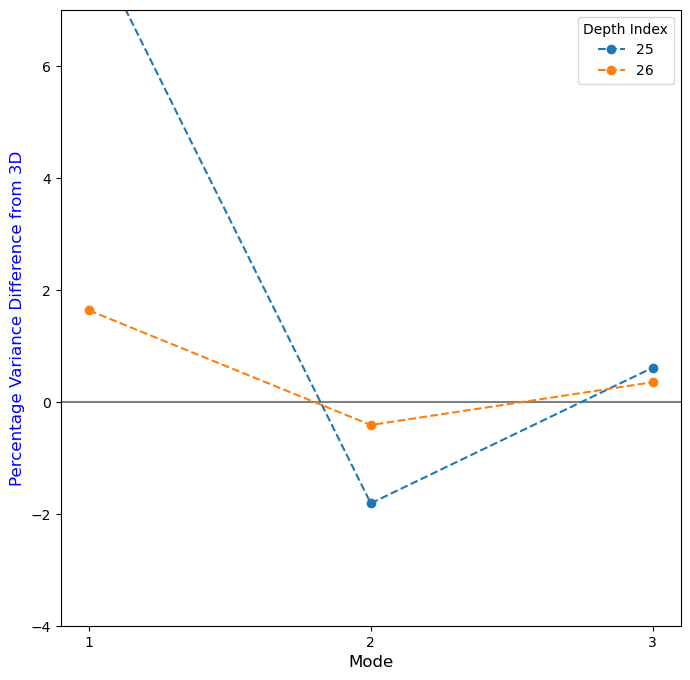

In [44]:
# fig, ax = plt.subplots()
   
# fig.set_size_inches(8., 8.)
# title_sz = 15
# label_sz = title_sz-3
# tick_sz = 5




# # formatting for left axis
# ax.set_ylabel("Percentage Variance Difference from 3D", size = label_sz)
# ax.set_ylim(-4, 7)
# ax.yaxis.label.set_color('blue')
# plt.xticks(fontsize= label_sz-2)


# # Format X axis
# ax.set_xticks([1,2,3])
# ax.set_xlabel("Mode", size = label_sz)

# plt.axhline(color = "grey")

# plt.legend(title="Depth Index")

# newDF[:3].plot(x = "Mode", y = ["25", "26"], style = "o--", ax = ax)


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


<Axes: xlabel='Mode', ylabel='Percentage Variance Difference from 3D'>

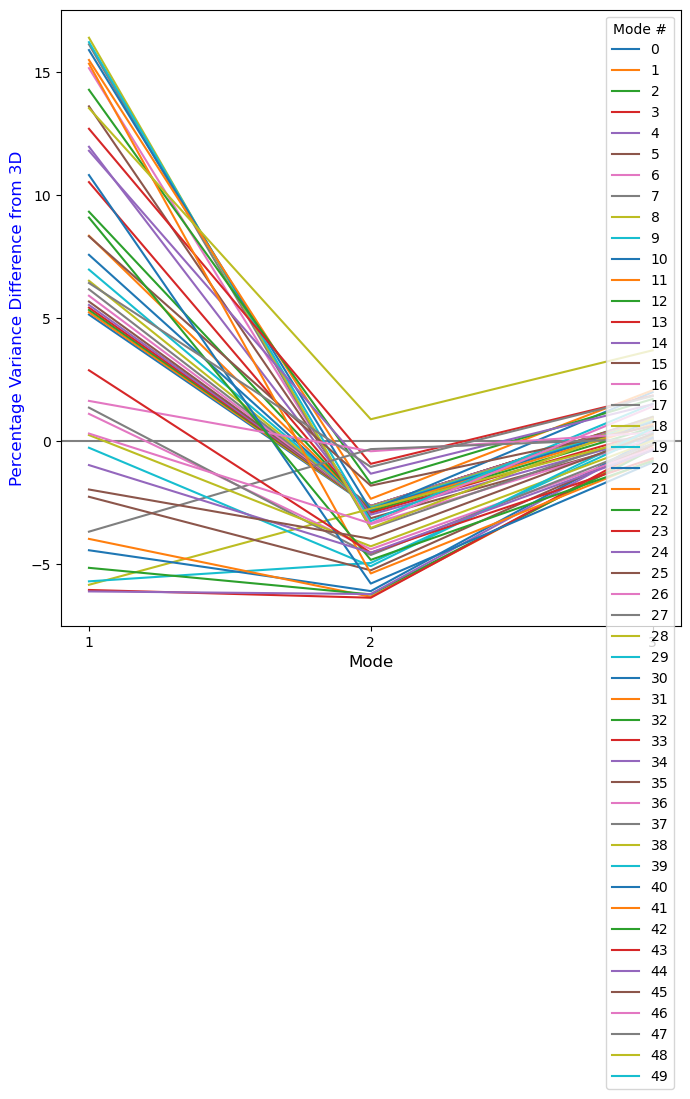

In [45]:
# fig, ax = plt.subplots()
   
# fig.set_size_inches(8., 8.)
# title_sz = 15
# label_sz = title_sz-3
# tick_sz = 5




# # formatting for left axis
# ax.set_ylabel("Percentage Variance Difference from 3D", size = label_sz)
# #ax.set_ylim(-5, 8)
# ax.yaxis.label.set_color('blue')
# plt.xticks(fontsize= label_sz-2)


# # Format X axis
# ax.set_xticks([1,2,3])
# ax.set_xlabel("Mode", size = label_sz)

# plt.axhline(color = "grey")

# plt.legend(title="Mode #")

# newDF[:3].plot(x = "Mode", ax = ax)

## Compute EOFs in parts

### Space time data matrix for one level:

### Space time anomaly Matrix:
$$
A[i,t] =
\begin{equation}
    \begin{pmatrix}
      \vec{a}_{l_1,Y_{1993}} & \vec{a}_{l_1,Y_{1994}} & ... & \vec{a}_{l_1,Y_{2021}} \\
      \vec{a}_{l_2,Y_{1993}} & \vec{a}_{l_2,Y_{1994}} & ... & \vec{a}_{l_2,Y_{2021}} \\
      \vec{a}_{l_3,Y_{1993}} & \vec{a}_{l_3,Y_{1994}} & ... & \vec{a}_{l_3,Y_{2021}} \\
      ...            & ...            & ...            & ...   & ...            & ...\\
      \vec{a}_{l_{32},Y_{1993}} & \vec{a}_{l_{32},Y_{1994}} & ... & \vec{a}_{l_{32},Y_{2021}} \\
    \end{pmatrix}
\end{equation}
$$
Where each vector $\vec{a}$ is an anomaly at a depth level $l$ and a timestep $Y$. Let an eigenvector be defined as $\vec{v_k}$ where $k$ is the eigenvector number or mode number. There are a total of Y modes that are used. Defining an eigenvector matrix:
\begin{equation}
V = 
\begin{pmatrix}
\vec{v}_1 & \vec{v}_2 & ... & \vec{v}_Y
\end{pmatrix}
\end{equation}
We can then define our EOFs as a result of dot product of the anomalies and eigenvectors devided by its magnitude:
\begin{equation}
EOF = \frac{AV}{||AV||}
\end{equation}

This algorithm breaks up this computation so that it reads anomalies a chunk at a time and writes to EOF files a chunk at a time. 



 
Consider a latitude longitude grid point($i$) that is not land $i \epsilon \omega$, or more formally in the domain of only ocean data $\omega$. Lets look at the 

In [16]:
month = 'Winter'

In [18]:
#################################################################################################################
#################################################################################################################
# Function checks if a file exists and if it does, continues to the next iteration.
# Input:
#         - file_path: string with the path name to folder
# Outputs:
#         - True if file doesnt exists
#         - False if file exists
# Important Variables: 
def check_file_and_continue(file_path):
    if os.path.exists(file_path):
        print(f"File '{file_path}' exists. Moving to next iteration.")
        return False
    else:
        return True
#################################################################################################################
#################################################################################################################
# Function reads in raw cut anomalies
# 
# Input:
#         - year: int with the specific year to read
# Output:
#         - anom: 3D array of dim (depth, lat, lon) with the anomaly data
def read_anom_raw(year):
    fn   = 'Winter.anom.mon.'+str(year)+'.nc'        # change directory
    fn   = os.path.join(anomalies_directory, fn)  # join with the directory that can be changed
    nc0 = ds(fn, 'r')
    anom = nc0.variables['anom'][:depth_end, lat_start:lat_end, lon_start:lon_end]
    anom = anom.filled()
    nc0.close()
    return anom
#################################################################################################################
#################################################################################################################
# Function reads anomaly data but only outputs matrix with no NaNs
# depth is specified to save RAM while reading. Without the specified depth you would be reading in all depths
# Input:
#         - year: int with the specific year to read
#         - depth: int with specified depth index not actual depth value. This is used to save space when reading in so we aren't reading in all depths 
#         - read: 2D array with indexes of what row and column has data. 
#                 read[:,0]- the rows with data
#                 read[:,1]- the columns with data
# Output:
#         - anom: 2D matrix at specified year and depth with no NaNs

def read_anom_parts(year,depth,read):
    fn   = 'Winter.anom.mon.'+str(year)+'.nc'        # change directory
    fn   = os.path.join(anomalies_directory, fn)  # join with the directory that can be changed
    nc0 = ds(fn, 'r')
    anom = nc0.variables['anom'][depth, lat_start:lat_end, lon_start:lon_end]
    anom = anom.filled()
    nc0.close()
    anom = anom[read[:,0], read[:,1]]
    return anom
#################################################################################################################
#################################################################################################################
# Function Created the files which will be aggregated a chunk at a time.
# The files must be created  first so we can more easily access and aggregate them.
# Input:
#         - total_modes: int with the total amount of modes I want. 
#                        Maximum is the total amount of time steps
# Output:
#         - None: the function will create files for all EOF modes
# Important Variables: 
def create_EOF_files(total_modes):
    create_folder(EOF_directory)                  # create folder 
    anom_base = read_anom_raw(1994)               # read in one anomaly to base the dimensions of EOF
    EOF_mat = np.full_like(anom_base, np.nan)     # create a matrix with the same dim size as the anomalies
    for mode in range(1,total_modes+1):           # for all the modes
        # Create a new NetCDF file
        fn = 'EOF_'+str(mode)+'.nc'               # file name for EOFs
        fn     = os.path.join(EOF_directory, fn)  # join with EOF path
        if not check_file_and_continue(fn):                      # if the file does already exist continue
            continue;
        ncfile = ds(fn, 'w', format='NETCDF4')                   # if the file doesnt exist create it
        
        # Define dimensions
        ncfile.createDimension('depth', EOF_mat.shape[0])
        ncfile.createDimension('lat', EOF_mat.shape[1])
        ncfile.createDimension('lon', EOF_mat.shape[2])
        
        # Create a variable for EOFs
        var = ncfile.createVariable('EOF', 'f4', ('depth', 'lat', 'lon'), fill_value = np.nan)
        #var = ncfile.createVariable('EOF', 'f4', ('lat', 'lon'), fill_value = np.nan)
        var[:] = EOF_mat # save the empty EOF
        ncfile.close()   # close the file
    print(f"Total of '{mode}' EOF files created")
#################################################################################################################
#################################################################################################################
# Function normalizes the EOFs by dividing by magnitude
# 
# Input:
#         - tot_modes: an int describing total amount of modes
# Output:
#         - None: saves the EOFs to the EOF files
# Important Variables:  
def normalize_EOFs(tot_modes):
    for mode in range(1,tot_modes+1):
        fn      = 'EOF_'+str(mode)+'.nc'
        fn      = os.path.join(EOF_directory, fn)     # join with EOF path
        EOF_ncfile = ds(fn, 'a')
        EOF     = EOF_ncfile.variables['EOF']
        EOF_mag = EOF[:].compressed()                      # flattens and gets rid of NaN
        EOF[:]  = EOF[:].filled()/np.linalg.norm(EOF_mag)  # divide by magnitude
        EOF_ncfile.close()
#################################################################################################################
#################################################################################################################
# Function computes EOFs in parts. 
# To save on RAM we exclude points with NaN when reading
# Input:
#         - years: 1D int array with all years to read in of the anomalies.
#                  Length of this will also be the max amount of modes
# Output:
#         - None: function saves all EOF modes in sperate files
# Important Variables: 
#         - total_modes: int of the total amount of modes to compute. The default is the max (see input for max)
#         - num_ind: 2D array that tells us which indexes have ocean data(excludes land/NaN).
#         - chunk_size: the total amount of grid points to read in each year. Remember we are excluding NaN so
#                       this is total grid points with data that we are reading in
#         - read: a subset of num_ind that contains a total of chunk_size indexes for that iteration. 
#                 This variable makes sure we are not reading the same chunk, and the for loop it is in makes
#                 sure we read to the end even if the last chunk is less than chunk_size
#         - anom_mat: 2D space time anomaly matrix without NaN. This is at most dim(chunk_size, Y)
#         - EOF_mat: 3D Array of size (depth, lat, lon). This contains the resulting EOFs from the 
#                    multiplication.  
#                   NOTE: this matrix does contain NaNs. We make sure that the resulting multiplacation goes
#                         to the correct index bny uising the variable read for the indexing. 
def compute_EOFs(years):
    start = time.time()                                      # for timing 
    total_modes = len(years)+1                               # total amount of modes to compute
    anom_base = read_anom_raw(1994)                          # read in one anomaly file for dimensions
    #i = 0
    for i in range(anom_base.shape[0]):                      # for each depth
        num_ind = np.argwhere(~np.isnan(anom_base[i,:,:]))   # for this depth, indexes with data
        # num_ind = np.argwhere(~np.isnan(anom_base[:,:]))   # for this depth, indexes with data
        chunk_size = 8000000                                 # read in this many ocean points a year
        print("Depth layer: ", i)
        for j in range(0,len(num_ind),chunk_size):           # read in a chunk at a time until done with depth
            read = num_ind[j:j+chunk_size]                   # read chunksize of ocean data(exclude land in reading)
            anom_mat = np.zeros((len(read),len(years)))      # initialize space time data matrix
            for k,y in enumerate(years):                     # for every year
                anom_mat[:,k] = read_anom_parts(y, i,read)   # read in ocean anomalies and put in matrix
            for mode in range(1,total_modes):                # for every mode
                # Open the EOF NetCDF file to write
                fn = 'EOF_'+str(mode)+'.nc'
                fn     = os.path.join(EOF_directory, fn)     # join with EOF path
                EOF_ncfile = ds(fn, 'a')                     # open to write (hence 'a')
                # Destination variable
                EOF = EOF_ncfile.variables['EOF']            # pointer to variable
                EOF_mat = EOF[:].filled()                    # get masked matrix and unmask it
                # compute EOFs and write to specified lat lon
                EOF_mat[i,read[:,0], read[:,1]] = anom_mat @ eigvecs[i,:,mode-1] # multiply to get EOFs
                # EOF_mat[read[:,0], read[:,1]] = anom_mat @ eigvecs[:,mode-1]   # multiply to get EOFs
                EOF[:] = EOF_mat                             # write to file
                EOF_ncfile.close()
    normalize_EOFs(len(years))
    end = time.time()
    print(end - start)

In [20]:
create_EOF_files(len(years))

Folder 'F:/GLORYS/2D EOFs/Winter Avg/Global/' already exists.
Total of '28' EOF files created


In [21]:
compute_EOFs(years)                    

49686.000615119934


## visualization

In [7]:
from mpl_toolkits.basemap import Basemap
import matplotlib as mpl
import matplotlib
from matplotlib import cm
from matplotlib.colors import ListedColormap, LinearSegmentedColormap
import matplotlib.pyplot as plt


# Depth and Mode of Interest
depth_ind = 27
mode = 2


# Read in files
fn      = 'EOF_'+str(mode)+'.nc'
fn      = os.path.join(EOF_directory, fn)     # join with EOF path
EOF_ncfile = ds(fn, 'r')
EOF = EOF_ncfile.variables['EOF']
EOF = EOF[:].filled()
EOF_ncfile.close()

# Calculate
area_weight = vol_weight(cut_depths, cut_lon, cut_lat)
EOF = EOF/area_weight  # remember to div by area weight 


print(fn)




# Correct negatively oriented layers by mode

if region == 'Pacific':
    # For Pacific
    noiseLayers1 = [8, 9, 10, 11, 14, 15, 16, 17, 18, 19, 21, 22, 24, 25, 28, 31]
    noiseLayers2 = [0, 4, 5, 9, 11, 14, 15, 16, 18, 20, 23, 25, 26, 27, 29, 30, 31]
    print('pacific')
elif region == "Global":
    noiseLayers1 = [8, 9, 10, 11, 14, 15, 16, 17, 18, 19, 21, 22, 24, 25, 28, 31]
    noiseLayers2 = [0, 3, 6, 7, 8, 9, 12, 13, 14, 16, 17, 21, 22, 23, 24, 25, 27, 28, 29, 30, 31, 32, 34, 36, 41, 45, 46, 47]
    print("global")

for i in range(depth_end):
    if (i in noiseLayers2) and (mode == 2):
        EOF[i, :, :] = -EOF[i, :, :]
    elif (i in noiseLayers1) and (mode == 1):
        EOF[i, :, :] = -EOF[i, :, :]


# if mode == 1:
#     clip = .00007 # Mode 1 clip
# else:
#     clip = 0.0001 # MOde 2 Clip





# Plot Formatting
title_sz = 19
label_sz = title_sz-3



depth = depths[depth_ind]



F:/GLORYS/2D EOFs/Winter Avg/Global/EOF_2.nc
glog


'\nfor i in range(depth_end):\n    if (i in noiseLayers2) and (mode == 2):\n        EOF[i, :, :] = -EOF[i, :, :]\n    elif (i in noiseLayers1) and (mode == 1):\n        EOF[i, :, :] = -EOF[i, :, :]\n\n\n# if mode == 1:\n#     clip = .00007 # Mode 1 clip\n# else:\n#     clip = 0.0001 # MOde 2 Clip\n\n\n\n\n\n# Plot Formatting\ntitle_sz = 19\nlabel_sz = title_sz-3\n\n\n\ndepth = depths[depth_ind]\n'

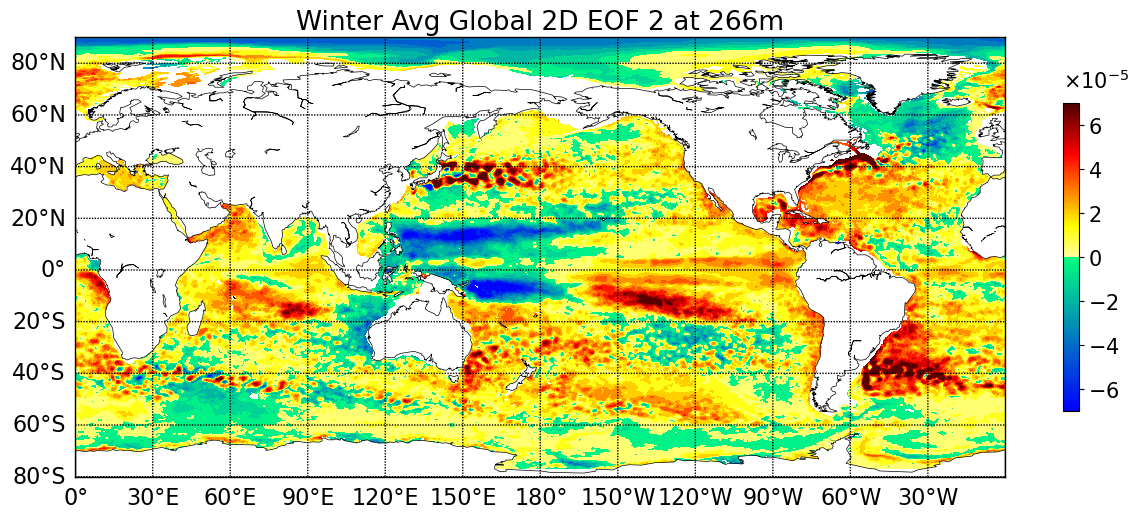

In [6]:
#clip = np.nanmax(abs(dat))
clip = 0.00007

#Plot first depth
fig, ax = plt.subplots(figsize=(15., 10.)) 

mymap = Basemap(projection='cyl',llcrnrlat=cut_lat[0],urcrnrlat=cut_lat[-1],llcrnrlon=cut_lon[0],urcrnrlon=cut_lon[-1],resolution='c')
mymap.drawcoastlines(color='black', linewidth=.5)
mymap.drawmapboundary()
mymap.drawparallels(np.arange(cut_lat[0],cut_lat[-1],20), labels = [1,0,0,0], fontsize = label_sz)
mymap.drawmeridians(np.arange(cut_lon[0],cut_lon[-1],30), labels = [0,0,0,1], fontsize = label_sz)

dat = EOF[depth_ind,:,:]

dat = np.maximum(np.minimum(dat, clip), -clip) # climp min and max values
norm = mpl.colors.Normalize(vmin=-clip, vmax=clip)
plt.contourf(cut_lon, cut_lat,  dat, 20, cmap = newcmp2, norm = norm)

if depth_ind == 0:
    plt.title(f"{month} {region} 2D EOF {mode} at Surface", size = title_sz)
else:    
    plt.title(f"{month} {region} 2D EOF {mode} at {round(depth)}m", size = title_sz)

sm = mpl.cm.ScalarMappable(norm=norm, cmap=newcmp2)
sm.set_array([]) 
cbar = plt.colorbar(sm, ax = ax, format = mpl.ticker.ScalarFormatter(useMathText=True), shrink = .4)
cbar.ax.yaxis.get_offset_text().set_fontsize(15) # change exp size
cbar.ax.yaxis.OFFSETTEXTPAD = 11           # moving exponent so it doesnt overlap with top of colorbar
cbar.ax.yaxis.set_offset_position('left')  # setexponent so it is more left 
cbar.ax.tick_params(labelsize=15)    # set label size of ticks
cbar.formatter.set_powerlimits((0, 0))     # formatting scientific notation
cbar.update_ticks()



saveName = "D:/SCIL/Paper Figs/" + region + "/DJF_" + region + "_depth" + str(depth_ind) + "_mode_" + str(mode) + "_2D"

plt.savefig(saveName)

F:/GLORYS/2D EOFs/Winter Avg/Pacific\EOF_2.nc


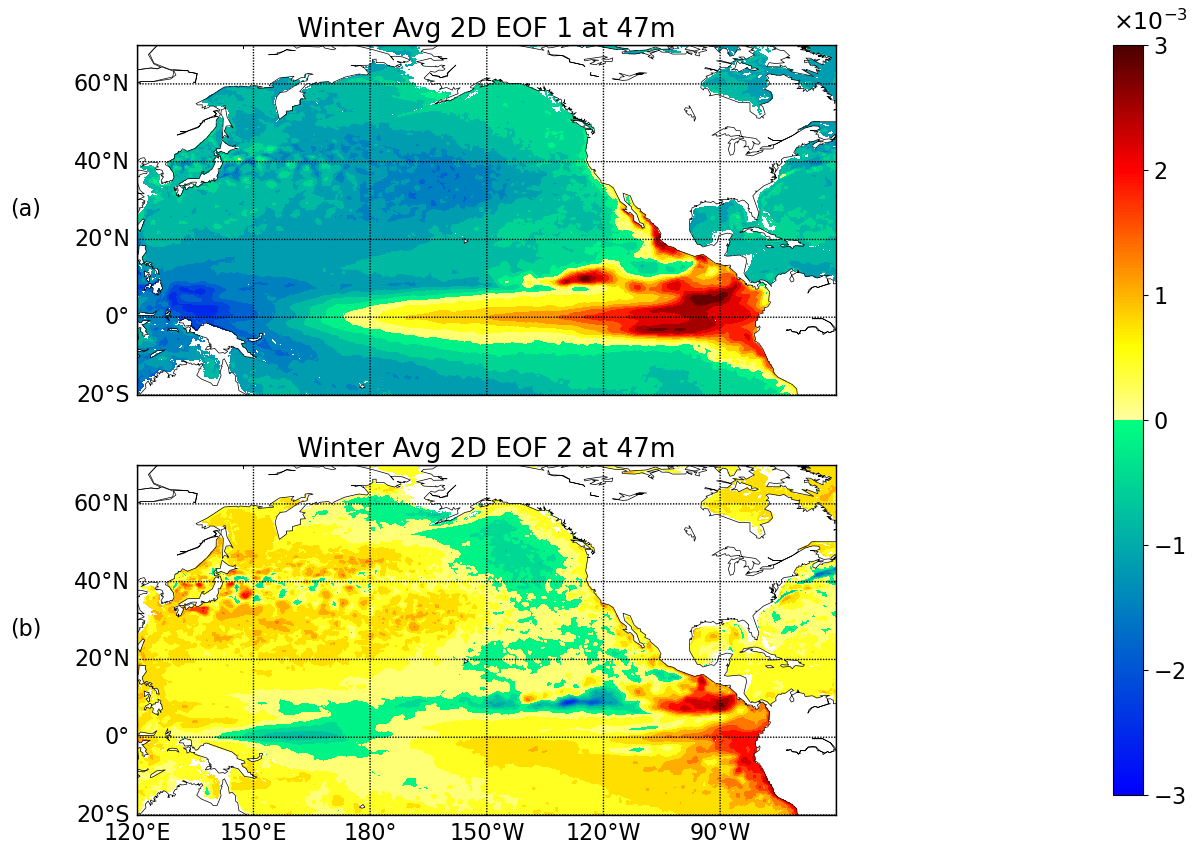

In [20]:

# depth = cut_depths[depth_ind]
# #
# clip = 0.003

# #Plot first depth
# fig = plt.figure(figsize=(15., 10.))

# #################################################################
# mode = 1
# fn      = 'EOF_'+str(mode)+'.nc'
# fn      = os.path.join(EOF_directory, fn)     # join with EOF path
# EOF_ncfile = ds(fn, 'r')
# EOF = EOF_ncfile.variables['EOF']
# EOF = EOF[:].filled()
# EOF_ncfile.close()

# area_weight = vol_weight(cut_depths, cut_lon, cut_lat)
# EOF = -EOF/area_weight  # remember to div by area weight 

# ax = fig.add_subplot(2,1,1)
# plt.ylabel('(a)', rotation = 'horizontal', size = label_sz,  labelpad=80)




# mymap = Basemap(projection='cyl',llcrnrlat=cut_lat[0],urcrnrlat=cut_lat[-1],llcrnrlon=cut_lon[0],urcrnrlon=cut_lon[-1],resolution='c')
# mymap.drawcoastlines(color='black', linewidth=.5)
# mymap.drawmapboundary()
# mymap.drawparallels(np.arange(cut_lat[0],cut_lat[-1],20), labels = [1,0,0,0], fontsize = label_sz)
# mymap.drawmeridians(np.arange(cut_lon[0],cut_lon[-1],30), labels = [0,0,0,0], fontsize = label_sz)


# dat = EOF[depth_ind,:,:]

# dat = np.maximum(np.minimum(dat, clip), -clip) # climp min and max values
# ax.contourf(cut_lon, cut_lat,  dat, 20, cmap = newcmp2)#, norm= norm)

# if depth_ind == 0:
#     plt.title(f"{month} 2D EOF {mode} at Surface", size = title_sz)
# else:
#     plt.title(f"{month} 2D EOF {mode} at {round(depth)}m", size = title_sz)


# #################################################################
# mode = 2
# fn      = 'EOF_'+str(mode)+'.nc'
# fn      = os.path.join(EOF_directory, fn)     # join with EOF path
# EOF_ncfile = ds(fn, 'r')
# EOF = EOF_ncfile.variables['EOF']
# EOF = EOF[:].filled()
# EOF_ncfile.close()


# print(fn)

# area_weight = vol_weight(cut_depths, cut_lon, cut_lat)
# EOF = -EOF/area_weight  # remember to div by area weight 

# ax = fig.add_subplot(2,1,2)
# plt.ylabel('(b)', rotation = 'horizontal',size = label_sz, labelpad=80)

# dat = EOF[depth_ind,:,:]
# dat = np.maximum(np.minimum(dat, clip), -clip) # climp min and max values


# mymap = Basemap(projection='cyl',llcrnrlat=cut_lat[0],urcrnrlat=cut_lat[-1],llcrnrlon=cut_lon[0],urcrnrlon=cut_lon[-1],resolution='c')
# mymap.drawcoastlines(color='black', linewidth=.5)
# mymap.drawmapboundary()
# mymap.drawparallels(np.arange(cut_lat[0],cut_lat[-1],20), labels = [1,0,0,0], fontsize = label_sz)
# mymap.drawmeridians(np.arange(cut_lon[0],cut_lon[-1],30), labels = [0,0,0,1], fontsize = label_sz)

# norm = mpl.colors.Normalize(vmin=-clip, vmax=clip)
# ax.contourf(cut_lon, cut_lat,  dat, 20, cmap = newcmp2)#, norm= norm)

# if depth_ind == 0:
#     plt.title(f"{month} 2D EOF {mode} at Surface", size = title_sz)
# else:
#     plt.title(f"{month} 2D EOF {mode} at {round(depth)}m", size = title_sz)


# cax = fig.add_axes([.93, 0.13, 0.02, 0.75]) #(left, bottom, width, height)
# sm = mpl.cm.ScalarMappable(norm=norm, cmap=newcmp2)
# sm.set_array([])
# cbar = plt.colorbar(sm, cax = cax, format = mpl.ticker.ScalarFormatter(useMathText=True))
# cbar.ax.yaxis.get_offset_text().set_fontsize(17) # change exp size
# cbar.ax.yaxis.OFFSETTEXTPAD = 11           # moving exponent so it doesnt overlap with top of colorbar
# cbar.ax.yaxis.set_offset_position('left')  # setexponent so it is more left
# cbar.ax.tick_params(labelsize=label_sz)    # set label size of ticks
# cbar.formatter.set_powerlimits((0, 0))     # formatting scientific notation
# cbar.update_ticks()
# plt.show()



In [33]:
mode = 2
fn      = 'EOF_'+str(mode)+'.nc'
fn      = os.path.join(EOF_directory, fn)     # join with EOF path
EOF_ncfile = ds(fn, 'r')
EOF = EOF_ncfile.variables['EOF']
EOF = EOF[:].filled()
EOF_ncfile.close()

area_weight = vol_weight(cut_depths, cut_lon, cut_lat)
EOF = EOF/area_weight  # remember to div by area weight 


noiseLayers1 = [8, 9, 10, 11, 14, 15, 16, 17, 18, 19, 21, 22, 24, 25, 28, 31]
noiseLayers2 = [0, 4, 5, 9, 11, 14, 15, 16, 18, 20, 23, 25, 26, 27, 29, 30, 31]


for i in range(depth_end):
    if (i in noiseLayers2) and (mode == 2):
        EOF[i, :, :] = -EOF[i, :, :]
    elif (i in noiseLayers1) and (mode == 1):
        EOF[i, :, :] = -EOF[i, :, :]



title_sz = 19
label_sz = title_sz-3
def f(depth_ind):
    depth = depths[depth_ind]
    
    
    
    #Plot first depth
    fig, ax = plt.subplots(figsize=(15., 10.)) 
    
    mymap = Basemap(projection='cyl',llcrnrlat=cut_lat[0],urcrnrlat=cut_lat[-1],llcrnrlon=cut_lon[0],urcrnrlon=cut_lon[-1],resolution='c')
    mymap.drawcoastlines(color='black', linewidth=.5)
    mymap.drawmapboundary()
    mymap.drawparallels(np.arange(cut_lat[0],cut_lat[-1],20), labels = [1,0,0,0], fontsize = label_sz)
    mymap.drawmeridians(np.arange(cut_lon[0],cut_lon[-1],30), labels = [0,0,0,1], fontsize = label_sz)
    
    dat = EOF[depth_ind,:,:]
    clip = np.nanmax(abs(dat)) # set min and max values
    # clip = .00007 
    clip = 0.0001
    dat = np.maximum(np.minimum(dat, clip), -clip) # climp min and max values
    norm = mpl.colors.Normalize(vmin=-clip, vmax=clip)
    plt.contourf(cut_lon, cut_lat,  dat, 20, cmap = newcmp2, norm = norm)
    
    if depth_ind == 0:
        plt.title(f"{month} EOF {mode} at Surface", size = title_sz)
    else:    
        plt.title(f"{month} EOF {mode} at {round(depth)}m", size = title_sz)
    
    sm = mpl.cm.ScalarMappable(norm=norm, cmap=newcmp2)
    sm.set_array([]) 
    cbar = plt.colorbar(sm, ax = ax, format = mpl.ticker.ScalarFormatter(useMathText=True), shrink = .4)
    cbar.ax.yaxis.get_offset_text().set_fontsize(15) # change exp size
    cbar.ax.yaxis.OFFSETTEXTPAD = 11           # moving exponent so it doesnt overlap with top of colorbar
    cbar.ax.yaxis.set_offset_position('left')  # setexponent so it is more left 
    cbar.ax.tick_params(labelsize=15)    # set label size of ticks
    cbar.formatter.set_powerlimits((0, 0))     # formatting scientific notation
    cbar.update_ticks()

interactive(f, depth_ind = (0,len(cut_depths)-1))

interactive(children=(IntSlider(value=24, description='depth_ind', max=49), Output()), _dom_classes=('widget-i…